# Mushroom Edibility Classification 
**Task:** Predict whether a mushroom is **edible (`e`)** or **poisonous (`p`)** from categorical features.
### Note
Misclassifying **poisonous as edible** is the most costly error. We tune models using **Recall for poisonous (`p`)**.

In [355]:
# Imports 
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split, StratifiedKFold, GridSearchCV
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    confusion_matrix, make_scorer
)

from sklearn.linear_model import LogisticRegression
from sklearn.naive_bayes import BernoulliNB
from sklearn.ensemble import RandomForestClassifier


## 1. Load Dataset
A folder 'Data' is created to store:
- `agaricus-lepiota.data`
- `agaricus-lepiota.names`

**Target label:** `class` -> {`e`, `p`}  
**Predictors:** remaining categorical columns.

In [357]:
# Column names from the UCI mushroom dataset 
COLUMNS = [
    'class',
    'cap-shape','cap-surface','cap-color','bruises','odor',
    'gill-attachment','gill-spacing','gill-size','gill-color',
    'stalk-shape','stalk-root',
    'stalk-surface-above-ring','stalk-surface-below-ring',
    'stalk-color-above-ring','stalk-color-below-ring',
    'veil-type','veil-color','ring-number','ring-type',
    'spore-print-color','population','habitat'
]


In [359]:
#Importing the dataset
import pandas as pd
df = pd.read_csv('Data/agaricus-lepiota.data', header=None, names=COLUMNS)
df.head()

,class,cap-shape,cap-surface,cap-color,bruises,odor,gill-attachment,gill-spacing,gill-size,gill-color,...,stalk-surface-below-ring,stalk-color-above-ring,stalk-color-below-ring,veil-type,veil-color,ring-number,ring-type,spore-print-color,population,habitat
0,p,x,s,n,t,p,f,c,n,k,...,s,w,w,p,w,o,p,k,s,u
1,e,x,s,y,t,a,f,c,b,k,...,s,w,w,p,w,o,p,n,n,g
2,e,b,s,w,t,l,f,c,b,n,...,s,w,w,p,w,o,p,n,n,m
3,p,x,y,w,t,p,f,c,n,n,...,s,w,w,p,w,o,p,k,s,u
4,e,x,s,g,f,n,f,w,b,k,...,s,w,w,p,w,o,e,n,a,g


In [361]:
print('Shape:', df.shape)
df.info()

Shape: (8124, 23)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8124 entries, 0 to 8123
Data columns (total 23 columns):
 #   Column                    Non-Null Count  Dtype 
---  ------                    --------------  ----- 
 0   class                     8124 non-null   object
 1   cap-shape                 8124 non-null   object
 2   cap-surface               8124 non-null   object
 3   cap-color                 8124 non-null   object
 4   bruises                   8124 non-null   object
 5   odor                      8124 non-null   object
 6   gill-attachment           8124 non-null   object
 7   gill-spacing              8124 non-null   object
 8   gill-size                 8124 non-null   object
 9   gill-color                8124 non-null   object
 10  stalk-shape               8124 non-null   object
 11  stalk-root                8124 non-null   object
 12  stalk-surface-above-ring  8124 non-null   object
 13  stalk-surface-below-ring  8124 non-null   object
 14  stalk-

## 2. Data Quality Checks
### 2.1 Missing marker check
The dataset uses `'?'` to represent unknown values (especially in `stalk-root`).

In [363]:
(df == '?').sum().sort_values(ascending=False)

stalk-root                  2480
stalk-surface-above-ring       0
population                     0
spore-print-color              0
ring-type                      0
ring-number                    0
veil-color                     0
veil-type                      0
stalk-color-below-ring         0
stalk-color-above-ring         0
stalk-surface-below-ring       0
class                          0
cap-shape                      0
stalk-shape                    0
gill-color                     0
gill-size                      0
gill-spacing                   0
gill-attachment                0
odor                           0
bruises                        0
cap-color                      0
cap-surface                    0
habitat                        0
dtype: int64

### 2.2 Replace missing markers
We replace `'?'` with a valid category **`missing`** to keep rows (lecture-friendly approach for categorical data).

In [365]:
df_clean = df.copy()
df_clean = df_clean.replace('?', pd.NA)
df_clean = df_clean.fillna('missing')
df_clean.isnull().sum().sort_values(ascending=False)

class                       0
stalk-surface-above-ring    0
population                  0
spore-print-color           0
ring-type                   0
ring-number                 0
veil-color                  0
veil-type                   0
stalk-color-below-ring      0
stalk-color-above-ring      0
stalk-surface-below-ring    0
stalk-root                  0
cap-shape                   0
stalk-shape                 0
gill-color                  0
gill-size                   0
gill-spacing                0
gill-attachment             0
odor                        0
bruises                     0
cap-color                   0
cap-surface                 0
habitat                     0
dtype: int64

### 2.3 Duplicate check
Duplicates can inflate performance if repeated patterns become overrepresented.

In [367]:
df_clean.duplicated().sum()

0

### 2.4 Constant feature check
Constant features do not help prediction and can be removed.

In [371]:
df_clean.nunique().sort_values()

veil-type                    1
class                        2
bruises                      2
gill-attachment              2
gill-spacing                 2
gill-size                    2
stalk-shape                  2
ring-number                  3
cap-surface                  4
veil-color                   4
stalk-surface-below-ring     4
stalk-surface-above-ring     4
ring-type                    5
stalk-root                   5
cap-shape                    6
population                   6
habitat                      7
stalk-color-above-ring       9
stalk-color-below-ring       9
odor                         9
spore-print-color            9
cap-color                   10
gill-color                  12
dtype: int64

In [373]:
# Drop constant (non-informative) column 
if 'veil-type' in df_clean.columns and df_clean['veil-type'].nunique() == 1:
    df_clean = df_clean.drop(columns=['veil-type'])

print('Updated shape:', df_clean.shape)

Updated shape: (8124, 22)


## 3.  Explanatory Data Analysis 
### 3.1 Class distribution
This confirms whether the dataset is imbalanced.

In [377]:
class_counts = df_clean['class'].value_counts()
class_counts

class
e    4208
p    3916
Name: count, dtype: int64

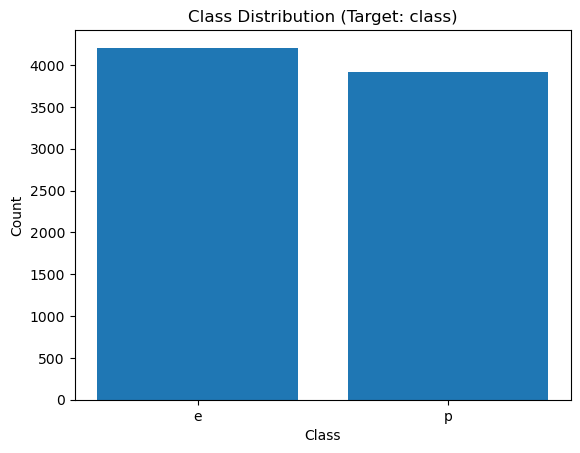

In [379]:
import matplotlib.pyplot as plt

plt.figure()
plt.bar(class_counts.index, class_counts.values)
plt.title('Class Distribution (Target: class)')
plt.xlabel('Class')
plt.ylabel('Count')
plt.show()

## 4. Train–Test Split 
**Important:** We split **before** any one-hot encoding. The test set is held out and used only at the end.

In [383]:
from sklearn.model_selection import train_test_split

X = df_clean.drop(columns=['class'])
y = df_clean['class']

# Target leakage check: 'class' must not be in X
print('class' in X.columns)

x_train, x_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

x_train.shape, x_test.shape, y_train.shape, y_test.shape

False


((6499, 21), (1625, 21), (6499,), (1625,))

### 4.1 Duplicate overlap check (train vs test)
If identical rows exist across train and test, results can be artificially inflated.

**Expected outcome:** 0 overlapping rows.

In [387]:
# Check exact row overlap between train and test (feature rows)
train_rows = set(map(tuple, x_train.values))
test_rows = set(map(tuple, x_test.values))
overlap = len(train_rows.intersection(test_rows))
overlap

0

## 5. Cross-Validation & Scoring Setup
 **Stratified 5-Fold CV** is used consistently across models.

**Primary tuning metric:** Recall for poisonous (`p`) because false negatives (poisonous → edible) are costly.

In [400]:
from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import make_scorer, recall_score
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

# Recall for poisonous as the positive class
recall_p = make_scorer(recall_score, pos_label='p')
cv, recall_p

(StratifiedKFold(n_splits=5, random_state=42, shuffle=True),
 make_scorer(recall_score, response_method='predict', pos_label=p))

## 6. Preprocessing (inside Pipeline)
All predictors are categorical, so we use **One-Hot Encoding**.

**Leakage control:** The encoder is fit only on training folds inside CV (handled automatically by Pipeline).

In [404]:
from sklearn.preprocessing import OneHotEncoder
# One-Hot Encoder for categorical variables
# sparse_output=False ensures compatibility with all models (including Random Forest)
ohe = OneHotEncoder(handle_unknown='ignore', sparse_output=False)


## 7. Model 1 — Logistic Regression (GridSearchCV)
**Why tune?** `C` controls regularization strength and `penalty` changes the regularization type.

**CV + tuning** are performed only on training data.

In [409]:
from sklearn.model_selection import GridSearchCV
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression

lr_pipe = Pipeline([
    ('ohe', ohe),
    ('model', LogisticRegression(solver='liblinear', max_iter=2000, random_state=42))
])

lr_param_grid = {
    'model__C': [0.1, 1, 10],
    'model__penalty': ['l1', 'l2']
}

lr_grid = GridSearchCV(
    lr_pipe,
    lr_param_grid,
    scoring=recall_p,
    cv=cv,
    n_jobs=-1
)

lr_grid.fit(x_train, y_train)
lr_grid.best_params_, lr_grid.best_score_
lr_grid

GridSearchCV(cv=StratifiedKFold(n_splits=5, random_state=42, shuffle=True),
             estimator=Pipeline(steps=[('ohe',
                                        OneHotEncoder(handle_unknown='ignore',
                                                      sparse_output=False)),
                                       ('model',
                                        LogisticRegression(max_iter=2000,
                                                           random_state=42,
                                                           solver='liblinear'))]),
             n_jobs=-1,
             param_grid={'model__C': [0.1, 1, 10],
                         'model__penalty': ['l1', 'l2']},
             scoring=make_scorer(recall_score, response_method='predict', pos_label=p))

In [410]:
from sklearn.metrics import accuracy_score, precision_score, f1_score

# Evaluate best Logistic Regression on hold-out test set
lr_best = lr_grid.best_estimator_
y_pred_lr = lr_best.predict(x_test)

acc_lr  = accuracy_score(y_test, y_pred_lr)
prec_lr = precision_score(y_test, y_pred_lr, pos_label='p')
rec_lr  = recall_score(y_test, y_pred_lr, pos_label='p')
f1_lr   = f1_score(y_test, y_pred_lr, pos_label='p')

acc_lr, prec_lr, rec_lr, f1_lr

(1.0, 1.0, 1.0, 1.0)

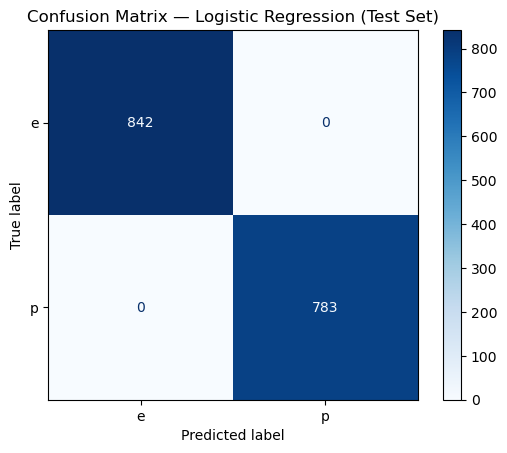

In [411]:
# Confusion matrix plot (Logistic Regression)

from sklearn.metrics import ConfusionMatrixDisplay
import matplotlib.pyplot as plt

ConfusionMatrixDisplay.from_predictions(
    y_test, y_pred_lr,
    labels=["e", "p"],
    display_labels=["e", "p"],
    cmap="Blues"
)
plt.title("Confusion Matrix — Logistic Regression (Test Set)")
plt.show()


## 8. Model 2 — Naïve Bayes (BernoulliNB) (GridSearchCV)
**Why tune?** `alpha` controls smoothing. Good smoothing helps generalization with many one-hot features.

In [413]:
from sklearn.naive_bayes import BernoulliNB

nb_pipe = Pipeline([
    ('ohe', ohe),
    ('model', BernoulliNB())
])

nb_param_grid = {
    'model__alpha': [0.1, 0.5, 1.0, 2.0]
}

nb_grid = GridSearchCV(
    nb_pipe,
    nb_param_grid,
    scoring=recall_p,
    cv=cv,
    n_jobs=-1
)

nb_grid.fit(x_train, y_train)
nb_grid.best_params_, nb_grid.best_score_
nb_grid

GridSearchCV(cv=StratifiedKFold(n_splits=5, random_state=42, shuffle=True),
             estimator=Pipeline(steps=[('ohe',
                                        OneHotEncoder(handle_unknown='ignore',
                                                      sparse_output=False)),
                                       ('model', BernoulliNB())]),
             n_jobs=-1, param_grid={'model__alpha': [0.1, 0.5, 1.0, 2.0]},
             scoring=make_scorer(recall_score, response_method='predict', pos_label=p))

In [414]:
# Evaluate best Naïve Bayes on hold-out test set
nb_best = nb_grid.best_estimator_
y_pred_nb = nb_best.predict(x_test)

acc_nb  = accuracy_score(y_test, y_pred_nb)
prec_nb = precision_score(y_test, y_pred_nb, pos_label='p')
rec_nb  = recall_score(y_test, y_pred_nb, pos_label='p')
f1_nb   = f1_score(y_test, y_pred_nb, pos_label='p')

acc_nb, prec_nb, rec_nb, f1_nb

(0.9581538461538461,
 0.9877216916780355,
 0.9246487867177522,
 0.9551451187335093)

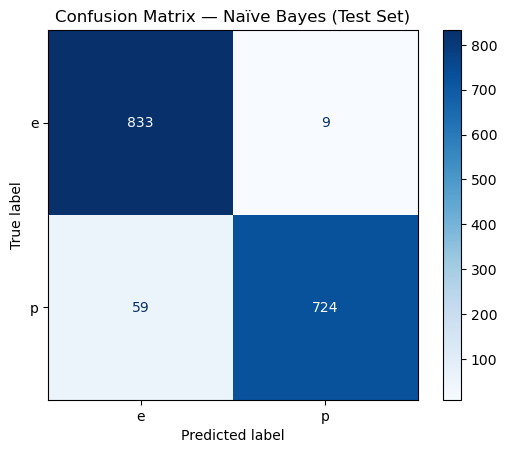

In [415]:
# Confusion matrix plot (Naïve Bayes)

from sklearn.metrics import ConfusionMatrixDisplay
import matplotlib.pyplot as plt

ConfusionMatrixDisplay.from_predictions(
    y_test, y_pred_nb,
    labels=["e", "p"],
    display_labels=["e", "p"],
    cmap="Blues"
)
plt.title("Confusion Matrix — Naïve Bayes (Test Set)")
plt.show()


## 9. Model 3 — Random Forest (GridSearchCV)
Random Forest can capture non-linear interactions between traits.

To avoid high bias, the search space includes enough flexibility while still controlling overfitting.

In [417]:
from sklearn.ensemble import RandomForestClassifier

rf_pipe = Pipeline([
    ('ohe', ohe),
    ('model', RandomForestClassifier(random_state=42))
])

rf_param_grid = {
    'model__n_estimators': [100, 300, 500],
    'model__max_depth': [None, 10, 20],
    'model__min_samples_split': [2, 5],
    'model__min_samples_leaf': [1, 2],
    'model__max_features': ['sqrt', 'log2']
}

rf_grid = GridSearchCV(
    rf_pipe,
    rf_param_grid,
    scoring=recall_p,
    cv=cv,
    n_jobs=-1
)

rf_grid.fit(x_train, y_train)
rf_grid.best_params_, rf_grid.best_score_
rf_grid

GridSearchCV(cv=StratifiedKFold(n_splits=5, random_state=42, shuffle=True),
             estimator=Pipeline(steps=[('ohe',
                                        OneHotEncoder(handle_unknown='ignore',
                                                      sparse_output=False)),
                                       ('model',
                                        RandomForestClassifier(random_state=42))]),
             n_jobs=-1,
             param_grid={'model__max_depth': [None, 10, 20],
                         'model__max_features': ['sqrt', 'log2'],
                         'model__min_samples_leaf': [1, 2],
                         'model__min_samples_split': [2, 5],
                         'model__n_estimators': [100, 300, 500]},
             scoring=make_scorer(recall_score, response_method='predict', pos_label=p))

In [418]:
# Evaluate best Random Forest on hold-out test set
rf_best = rf_grid.best_estimator_
y_pred_rf = rf_best.predict(x_test)

acc_rf  = accuracy_score(y_test, y_pred_rf)
prec_rf = precision_score(y_test, y_pred_rf, pos_label='p')
rec_rf  = recall_score(y_test, y_pred_rf, pos_label='p')
f1_rf   = f1_score(y_test, y_pred_rf, pos_label='p')

acc_rf, prec_rf, rec_rf, f1_rf

(1.0, 1.0, 1.0, 1.0)

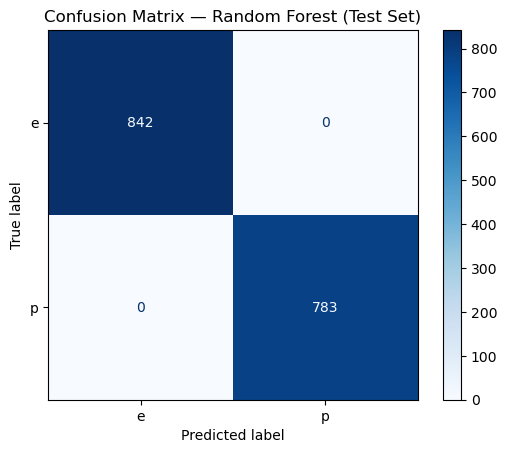

In [419]:
# Confusion matrix plot (Random Forest)

from sklearn.metrics import ConfusionMatrixDisplay
import matplotlib.pyplot as plt

ConfusionMatrixDisplay.from_predictions(
    y_test, y_pred_rf,
    labels=["e", "p"],
    display_labels=["e", "p"],
    cmap="Blues"
)
plt.title("Confusion Matrix — Random Forest (Test Set)")
plt.show()


## 10. Comparison Table + Bar Charts
Comparison is based on **test set** performance (unseen data).

In [421]:
results_table = pd.DataFrame({
    'Model': ['Logistic Regression', 'Naïve Bayes', 'Random Forest'],
    'CV Best Recall(p)': [lr_grid.best_score_, nb_grid.best_score_, rf_grid.best_score_],
    'Test Accuracy': [acc_lr, acc_nb, acc_rf],
    'Test Precision(p)': [prec_lr, prec_nb, prec_rf],
    'Test Recall(p)': [rec_lr, rec_nb, rec_rf],
    'Test F1(p)': [f1_lr, f1_nb, f1_rf]
})
results_table

,Model,CV Best Recall(p),Test Accuracy,Test Precision(p),Test Recall(p),Test F1(p)
0,Logistic Regression,0.999362,1.000000,1.000000,1.000000,1.000000
1,Naïve Bayes,0.917980,0.958154,0.987722,0.924649,0.955145
2,Random Forest,1.000000,1.000000,1.000000,1.000000,1.000000


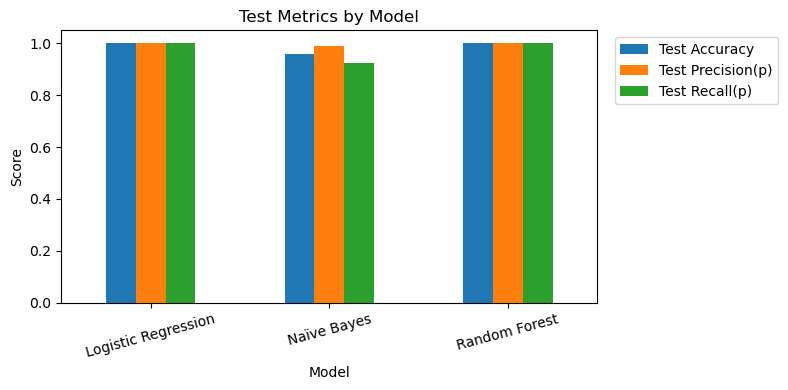

In [422]:
import matplotlib.pyplot as plt

results_table.set_index("Model")[["Test Accuracy", "Test Precision(p)", "Test Recall(p)"]].plot(
    kind="bar",
    figsize=(8,4)
)

plt.title("Test Metrics by Model")
plt.ylabel("Score")
plt.xticks(rotation=15)
plt.legend(loc="upper left", bbox_to_anchor=(1.02, 1))
plt.tight_layout()
plt.show()


In [423]:
import pandas as pd
from sklearn.metrics import accuracy_score, precision_score, recall_score, confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

# True labels for the same 100 rows you predicted
y_true_100 = df_clean.loc[X_100.index, "class"]          # 'e' or 'p'
y_pred_100 = best_model.predict(X_100)                  # 'e' or 'p'

# Table: actual vs predicted
check_100 = pd.DataFrame({
    "Actual": y_true_100.map({"e": "Edible", "p": "Poisonous"}),
    "Predicted": pd.Series(y_pred_100, index=X_100.index).map({"e": "Edible", "p": "Poisonous"})
})
check_100["Correct?"] = (check_100["Actual"] == check_100["Predicted"])

display(check_100.head(20))
print("Correct predictions:", check_100["Correct?"].sum(), "/ 100")

# Metrics (treat poisonous as the positive class)
acc = accuracy_score(y_true_100, y_pred_100)
prec = precision_score(y_true_100, y_pred_100, pos_label="p")
rec = recall_score(y_true_100, y_pred_100, pos_label="p")

print(f"Accuracy:  {acc:.4f}")
print(f"Precision (poisonous): {prec:.4f}")
print(f"Recall (poisonous):    {rec:.4f}")


,Actual,Predicted,Correct?
1971,Edible,Edible,True
6654,Poisonous,Poisonous,True
5606,Poisonous,Poisonous,True
3332,Edible,Edible,True
6988,Poisonous,Poisonous,True
5761,Poisonous,Poisonous,True
5798,Poisonous,Poisonous,True
3064,Poisonous,Poisonous,True
1811,Edible,Edible,True
3422,Edible,Edible,True


Correct predictions: 100 / 100
Accuracy:  1.0000
Precision (poisonous): 1.0000
Recall (poisonous):    1.0000


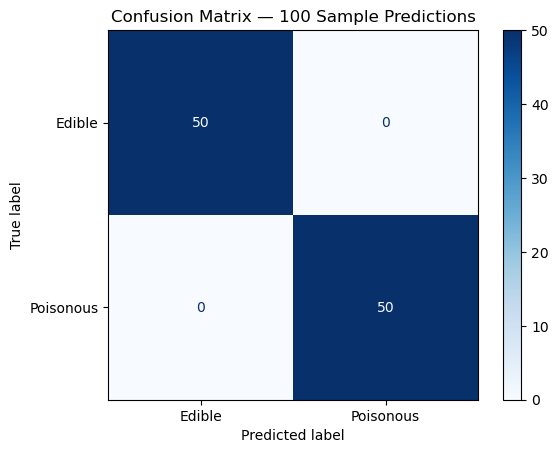

In [443]:
# Confusion matrix for the 100 rows

from sklearn.metrics import ConfusionMatrixDisplay
import matplotlib.pyplot as plt

ConfusionMatrixDisplay.from_predictions(
    y_true_100, y_pred_100,
    labels=["e", "p"],
    display_labels=["Edible", "Poisonous"],
    cmap="Blues"
)
plt.title("Confusion Matrix — 100 Sample Predictions")
plt.show()


In [447]:
# Model export for CLI usage
import joblib

X = df_clean.drop(columns=["class"])
y = df_clean["class"]

best_model = rf_grid.best_estimator_  
best_model.fit(X, y)

joblib.dump(best_model, "mushroom_model.joblib")
print("Saved mushroom_model.joblib")


Saved mushroom_model.joblib


In [449]:
"""
Mushroom Edibility Predictor (CLI)

Purpose
-------
This script loads a trained scikit-learn Pipeline (saved as a .joblib file)
and performs a single prediction for mushroom edibility.

Key Notes
---------
- The UCI Agaricus-Lepiota dataset stores each mushroom instance as:
    class, cap-shape, cap-surface, ..., habitat
  where:
    class = 'e' (edible) or 'p' (poisonous)

- For prediction, the CLI accepts ONLY the 22 feature codes (no class label).
  This prevents the true label from being revealed during demonstration.

Input Format Accepted
---------------------
- 22 values: [22 feature codes only] in the dataset feature order (excluding class)

File Requirements
-----------------
- mushroom_model.joblib must exist in the same folder as this script.
"""

import joblib
import pandas as pd


# Full dataset column order (as documented in agaricus-lepiota.names).
# Note: The first column is the target label ('class') and is NOT entered in the CLI.
COLUMNS = [
    "class",
    "cap-shape",
    "cap-surface",
    "cap-color",
    "bruises",
    "odor",
    "gill-attachment",
    "gill-spacing",
    "gill-size",
    "gill-color",
    "stalk-shape",
    "stalk-root",
    "stalk-surface-above-ring",
    "stalk-surface-below-ring",
    "stalk-color-above-ring",
    "stalk-color-below-ring",
    "veil-type",
    "veil-color",
    "ring-number",
    "ring-type",
    "spore-print-color",
    "population",
    "habitat",
]


def main() -> None:
    """
    Run a single prediction from terminal input.

    Workflow:
    1) Load the trained model pipeline from disk.
    2) Read one comma-separated row from the user (22 feature values).
    3) Clean input values to match notebook cleaning rules (e.g., '?' -> 'missing').
    4) Build a one-row DataFrame with the exact feature columns expected by the model.
    5) Predict edible/poisonous and display results.
    """

    # 1) Load the trained model pipeline
    # The saved object is a scikit-learn Pipeline (e.g., OneHotEncoder + model),
    # trained in the notebook and exported using joblib.
    model = joblib.load("mushroom_model.joblib")

    # 2) Determine the exact input features expected by the trained model
    # This prevents feature mismatch errors (e.g., if a constant column was dropped in training).
    features = list(model.feature_names_in_)

    # 3) Prompt the user for one row of input (22 feature codes only)
    print("\nMushroom Edibility Predictor")
    print("Paste 22 comma-separated feature codes (NO class label).")
    print("Order (dataset features, excluding class):")
    print(", ".join(COLUMNS[1:]))
    print("\nExample (22 values):")
    print("x,s,n,t,p,f,c,n,k,e,e,s,s,w,w,p,w,o,p,k,s,u\n")

    line = input("Row> ").strip()

    # Split the input line into individual values
    parts = [p.strip() for p in line.split(",")]

    # 4) Validate input length (must be exactly 22 feature values)
    if len(parts) != 22:
        raise ValueError(f"Input must have exactly 22 values (features only). Got {len(parts)}.")

    values = parts

    # 5) Apply the same missing-value handling used in the notebook
    # In this dataset, missing values are encoded as '?' (typically for stalk-root).
    # In the notebook, these were replaced with the category label 'missing'.
    values = ["missing" if v == "?" else v for v in values]

    # 6) Map the 22 input values to the dataset feature names (excluding 'class')
    # This creates a full "feature name -> value" mapping in the original dataset order.
    full_row = dict(zip(COLUMNS[1:], values))

    # 7) Create a one-row DataFrame using the exact features expected by the model
    # The model may not require all dataset columns (e.g., 'veil-type' can be dropped if constant),
    # so the DataFrame is built strictly in the model's expected feature order.
    X_one = pd.DataFrame([[full_row[f] for f in features]], columns=features)

    # 8) Predict and display results
    # Model prediction is expected to be 'e' or 'p'.
    pred = model.predict(X_one)[0]
    pred_text = "Edible" if pred == "e" else "Poisonous"

    print(f"\nPrediction: {pred_text} ({pred})")


if __name__ == "__main__":
    main()



Mushroom Edibility Predictor
Paste 22 comma-separated feature codes (NO class label).
Order (dataset features, excluding class):
cap-shape, cap-surface, cap-color, bruises, odor, gill-attachment, gill-spacing, gill-size, gill-color, stalk-shape, stalk-root, stalk-surface-above-ring, stalk-surface-below-ring, stalk-color-above-ring, stalk-color-below-ring, veil-type, veil-color, ring-number, ring-type, spore-print-color, population, habitat

Example (22 values):
x,s,n,t,p,f,c,n,k,e,e,s,s,w,w,p,w,o,p,k,s,u



Row>  x,s,n,t,p,f,c,n,k,e,e,s,s,w,w,p,w,o,p,k,s,u



Prediction: Poisonous (p)
